In [ ]:
import h5py
import urllib.request
url = "https://portal.nersc.gov/cfs/m2986/cosmon/nn_c103_2505.05547/cosmon_c103_r005-8_nucleon.hdf5"
file_path = "cosmon_c103_r005-8_nucleon.hdf5"
urllib.request.urlretrieve(url, file_path)
with h5py.File(file_path, "r") as f:
    print(list(f.keys()))
    f.visit(lambda x: print(x))
    print("\nDatasets:")
    def show(name):
        if isinstance(f[name], h5py.Dataset):
            print(name, f[name].shape, f[name].dtype)
    f.visit(show)
    print("\nAttributes:")
    for k, v in f.attrs.items():
        print(k, v)

['P000_G1g_1', 'P000_G1g_2', 'P001_G1_1', 'P001_G1_2', 'P002_G1_1', 'P002_G1_2', 'P00m1_G1_1', 'P00m1_G1_2', 'P00m2_G1_1', 'P00m2_G1_2', 'P010_G1_1', 'P010_G1_2', 'P011_G_1', 'P011_G_2', 'P012_F1_1', 'P012_F2_1', 'P01m1_G_1', 'P01m1_G_2', 'P01m2_F1_1', 'P01m2_F2_1', 'P020_G1_1', 'P020_G1_2', 'P021_F1_1', 'P021_F2_1', 'P02m1_F1_1', 'P02m1_F2_1', 'P0m10_G1_1', 'P0m10_G1_2', 'P0m11_G_1', 'P0m11_G_2', 'P0m12_F1_1', 'P0m12_F2_1', 'P0m1m1_G_1', 'P0m1m1_G_2', 'P0m1m2_F1_1', 'P0m1m2_F2_1', 'P0m20_G1_1', 'P0m20_G1_2', 'P0m21_F1_1', 'P0m21_F2_1', 'P0m2m1_F1_1', 'P0m2m1_F2_1', 'P100_G1_1', 'P100_G1_2', 'P101_G_1', 'P101_G_2', 'P102_F1_1', 'P102_F2_1', 'P10m1_G_1', 'P10m1_G_2', 'P10m2_F1_1', 'P10m2_F2_1', 'P110_G_1', 'P110_G_2', 'P111_G_1', 'P111_G_2', 'P11m1_G_1', 'P11m1_G_2', 'P120_F1_1', 'P120_F2_1', 'P1m10_G_1', 'P1m10_G_2', 'P1m11_G_1', 'P1m11_G_2', 'P1m1m1_G_1', 'P1m1m1_G_2', 'P1m20_F1_1', 'P1m20_F2_1', 'P200_G1_1', 'P200_G1_2', 'P201_F1_1', 'P201_F2_1', 'P20m1_F1_1', 'P20m1_F2_1', 'P210_F1_

(1490, 26) (1490, 26)


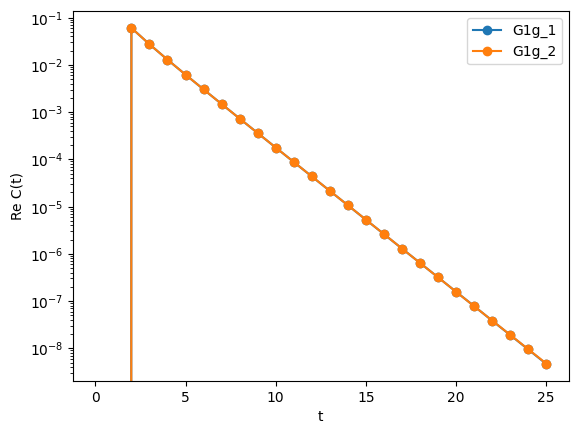

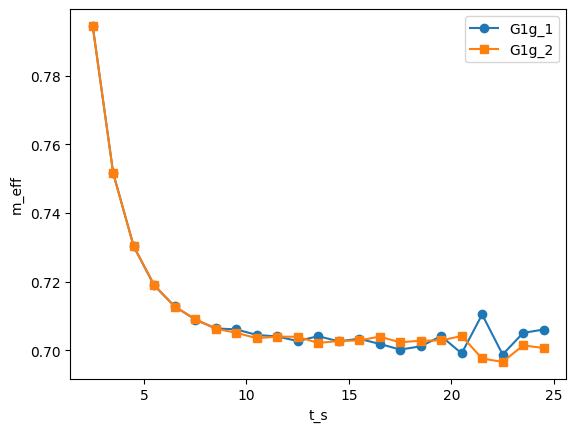

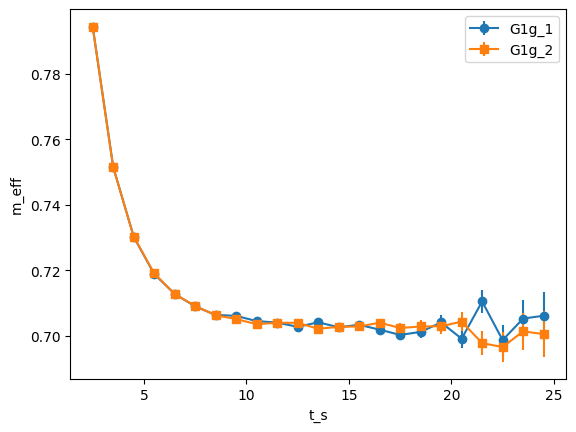

t_s = 2.5
G1g_1: 0.7945076286122031 +/- 0.0002374165677159866
G1g_2: 0.7944463742413067 +/- 0.0002370732191329059


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
file_path = "cosmon_c103_r005-8_nucleon.hdf5"
with h5py.File(file_path, "r") as f:
    # reference this is operator O_i in Sarah thesis eq 4.1
    d1=f["P000_G1g_1/data"][:]
    # d1[s,t]=one Monte Carlo sample s of C_11(t)
    d2=f["P000_G1g_2/data"][:]
    # d2[s,t]=one Monte Carlo sample s of C_22(t)
# Confirming the shapes
print(d1.shape,d2.shape)

# reference this is ensemble avg of c_ij(t) in sarah eq 4.1 result C1[t] is correlator whose spectral decomposition is eq 4.2
# C(t)=sum_n |Z_n|^2 e^{-E_n t}
C1=d1.mean(axis=0)
C2=d2.mean(axis=0)
t=np.arange(len(C1)) # time array

# plot of raw correlator log scale if C(t) ~ A e^{-E t}, then ln C(t) ~ ln A - E t which is ax+b here curvature refers to multiple state contribution
# reference sarah eq 4.2 and paper eq 2.1
plt.figure()
plt.plot(t,C1.real, "o-",label="G1g_1")
plt.plot(t,C2.real, "o-",label="G1g_2")
plt.yscale("log")
plt.xlabel("t")
plt.ylabel("Re C(t)")
plt.legend()
plt.savefig("nucleon_raw_correlator.png", dpi=150, bbox_inches="tight")
plt.show()

"""
Compute the effective mass from the correlator C(t)
For dt = 1 we use m_eff(t) = ln[C(t) / C(t+1)]
This is the same as Sarah's Eq. 4.4. The paper writes it at half-integer
times as: m_eff(t_s) = ln[C(t_s - 0.5) / C(t_s + 0.5)]
So, choosing t_s = t + 0.5 gives the same expression
"""
def effective_mass(C, t_start=2):
    # Using real part because imaginary part is noise
    C=C.real
    ts=np.arange(t_start,len(C)-1)+0.5
    # Supress numpy warning on division by zero, we will convert them them non physical value to NaN
    with np.errstate(divide="ignore", invalid="ignore"):
        # C[t_start:-1]  = C[2], C[3], so on till C[24]   (numerator)
        # C[t_start+1:]  = C[3], C[4], so on till C[25]   (denominator)
        # The ratio at index i is C[2+i] / C[3+i] aligned with ts[i]
        m=np.log(C[t_start:-1]/C[t_start + 1:])
        # Drop any val where effective mass <= 0
        m=np.where(m>0,m,np.nan)
    return ts, m

# Apply the function to both correlators ts is same for both so we discard it for second call
ts,m1=effective_mass(C1)
_,m2=effective_mass(C2)
# plot
"""
reference is sarah eq 4.5 where lim t _> inf effective mass -> E_0
Paper eq 2.15 give am_N=0.7026(40) which is what the plateau should approach large time slice
"""
plt.figure()
plt.plot(ts,m1,"o-",label="G1g_1")
plt.plot(ts,m2,"s-",label="G1g_2")
plt.xlabel("t_s")
plt.ylabel("m_eff")
plt.legend()
plt.show()

"""
Bootstrap the effective mass by resampling the 1490 configurations with replacement then for each bootstrap sample calculate the mean correlator and then recompute m_eff Repeat this nboot times.

Since we have only one correlator there is no GEVP or pivot involved
for a single correlator sarah's bootstrap procedure simply reduces
to resampliing the configurations and calculating m_eff from each
resampled mean correlator and
returns an array of shape (nboot, n_t), with n_t = 23.
"""
def bootstrap_meff(data, nboot=1000, seed=12345):
    rng=np.random.default_rng(seed)
    ns=data.shape[0]
    samples = []
    for _ in range(nboot):
        idx = rng.integers(ns, size=ns) # draw ns sample indices with replacement
        C = data[idx].mean(axis=0).real # recompute the mean correlator from resample
        # Same index scheme as effective mass above
        # C[2:-1] = c[2], so on till c[24], C[3:] = c[3], so on till c[25]
        # Ratio at index i=c[2+i]/c[3+i]
        with np.errstate(divide="ignore", invalid="ignore"):
            m = np.log(C[2:-1] / C[3:])
            m = np.where(m > 0, m, np.nan)
        samples.append(m)
    return np.array(samples) # shape is nbootX3

b1 = bootstrap_meff(d1)
b2 = bootstrap_meff(d2)
m1_avg = np.nanmean(b1, axis=0) # Ignore NaN values
m1_err = np.nanstd(b1, axis=0) # gives bootstrap stddev
m2_avg = np.nanmean(b2, axis=0)
m2_err = np.nanstd(b2, axis=0)
# plot paper figure 1 middle one meffective = ln(C(t_s-0.5)/C(t_s+0.5))
# then at time slice = 2. the paper shows effective mass 0.75 to 0.83
plt.figure()
plt.errorbar(ts, m1_avg, yerr=m1_err, fmt="o-", label="G1g_1")
plt.errorbar(ts, m2_avg, yerr=m2_err, fmt="s-", label="G1g_2")
plt.xlabel("t_s")
plt.ylabel("m_eff")
plt.legend()
plt.savefig("nucleon_effective_mass.png", dpi=150, bbox_inches="tight")
plt.show()

# find the closest value in our t_s array
i = np.argmin(abs(ts - 2.5))

print("t_s = 2.5")
print("G1g_1:", m1_avg[i], "+/-", m1_err[i])
print("G1g_2:", m2_avg[i], "+/-", m2_err[i])

# Our values should be approximately:
# G1g_1: 0.7945 +/- 0.000237
# G1g_2: 0.7944 +/- 0.000237
#
# These are consistent with the range shown in Figure 1 (~0.75–0.83).
# at larger t_s the effective mass approaches the nucleon mass
# am_N = 0.70267(40) given in eq 2.15

N_samples = 1490  Nt = 26
t_min = 3, t_max = 10: E0 = 0.719252 +/- 0.000137
t_min = 4, t_max = 10: E0 = 0.713860 +/- 0.000150
t_min = 5, t_max = 10: E0 = 0.710585 +/- 0.000165
t_min = 6, t_max = 10: E0 = 0.708518 +/- 0.000189
t_min = 7, t_max = 10: E0 = 0.707106 +/- 0.000221
t_min = 4, t_max = 8: E0 = 0.717697 +/- 0.000164
t_min = 4, t_max = 9: E0 = 0.715424 +/- 0.000154
t_min = 4, t_max = 10: E0 = 0.713860 +/- 0.000150
t_min = 4, t_max = 11: E0 = 0.712514 +/- 0.000152
t_min = 4, t_max = 12: E0 = 0.711449 +/- 0.000157
t_min = 4, t_max = 13: E0 = 0.710475 +/- 0.000159


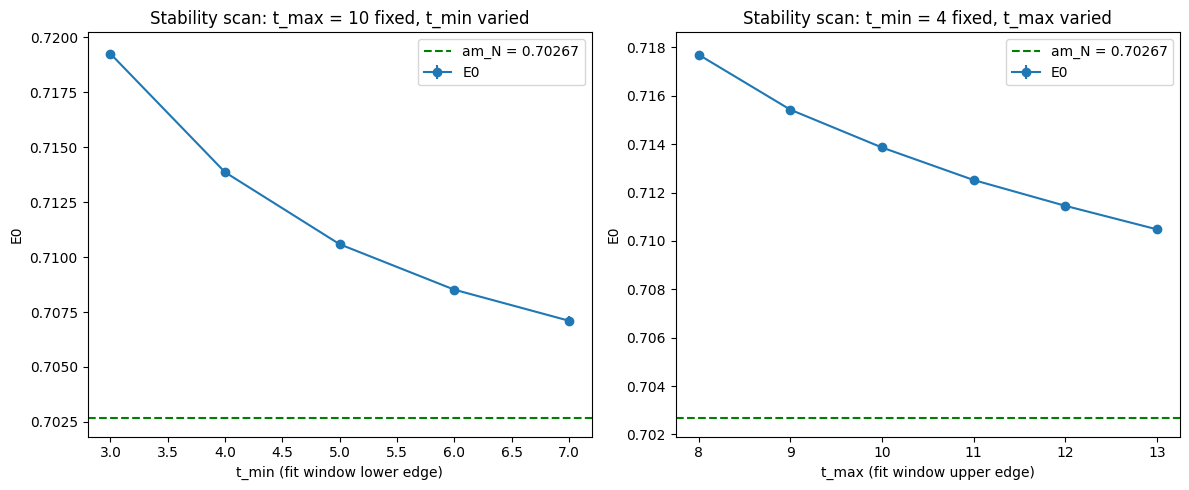


Single-exp fit over t in [4, 10]:
  A    = 0.233348
  E0   = 0.724506 +/- 0.000184


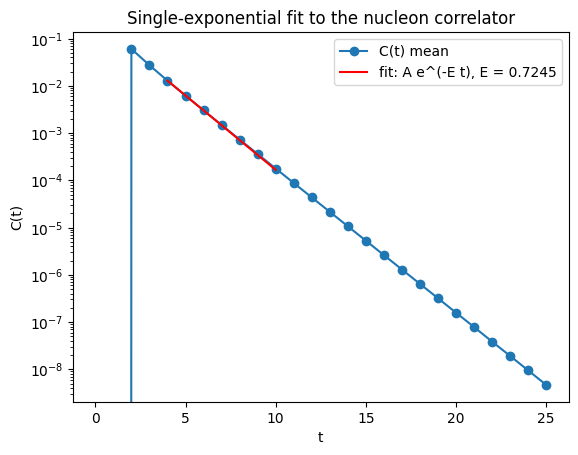

Constant fit to m_eff over t_s in [4.5, 10.5]:
E0 = 0.712513 +/- 0.003232


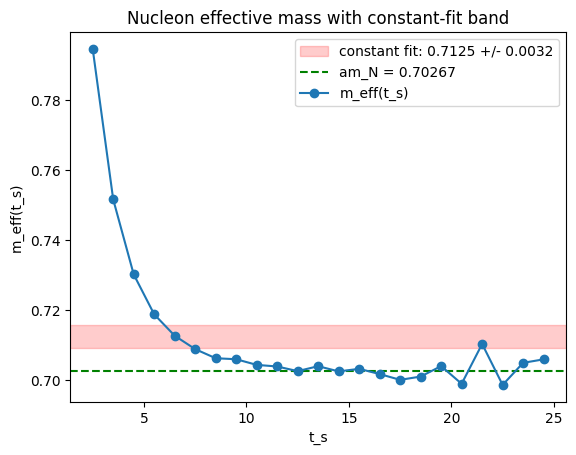

In [ ]:
#stability scan and single exponential fit
#phy ref thesis:
#     eq 4.2 : C(t) = sum_n |Z_n|^2 e^{-E_n t}
#     eq 4.4 : m_eff(t) = -(1/dt)[ ln C(t+dt) - ln C(t) ]
#     eq 4.5 : lim_{t->inf} m_eff(t) -> E_0
#   Paper arXiv:2505.05547:
#     eq 2.1 : C(t) = sum_n |Z_n|^2 e^{-E_n t}
#     Figure 1 caption: m_eff(t_s) = ln(C(t_s-0.5)/C(t_s+0.5))
#     Figure 1 middle panel: nucleon m_eff at t_s = 2.5
#     eq 2.15 : am_N = 0.70267(40)

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
file_path = "cosmon_c103_r005-8_nucleon.hdf5"
with h5py.File(file_path, "r") as f:
    d1 = f["P000_G1g_1/data"][:]   # (1490, 26)
    d2 = f["P000_G1g_2/data"][:]   # (1490, 26)
N_samples, Nt = d1.shape
print("N_samples =", N_samples, " Nt =", Nt)
t_min_scan = [3, 4, 5, 6, 7]
t_max_fixed = 10

def effective_mass(C, t_start=2):
    C=C.real
    ts=np.arange(t_start, len(C) - 1) + 0.5
    with np.errstate(divide="ignore", invalid="ignore"):
        m=np.log(C[t_start:-1] / C[t_start + 1:])
        m=np.where(m > 0, m, np.nan)
    return ts, m

def bootstrap_E0(d, t_min, t_max, nboot=1000, seed=12345, t_start=2):
    rng=np.random.default_rng(seed)
    Ns=d.shape[0]
    E0_boot=np.full(nboot, np.nan)

    for b in range(nboot):
        idx=rng.integers(0, Ns, size=Ns)
        Cb=d[idx].mean(axis=0).real
        ts_b,m_b=effective_mass(Cb, t_start=t_start)
        mask=(ts_b >= t_min) & (ts_b <= t_max)
        E0_boot[b]=np.nanmean(m_b[mask])
    return np.nanmean(E0_boot), np.nanstd(E0_boot)

#scan t_min with t_max fixed
E0_vs_tmin = []
E0err_vs_tmin = []
for tmin in t_min_scan:
    E0, E0err = bootstrap_E0(d1, tmin, t_max_fixed)
    E0_vs_tmin.append(E0)
    E0err_vs_tmin.append(E0err)
    print(f"t_min = {tmin}, t_max = {t_max_fixed}: E0 = {E0:.6f} +/- {E0err:.6f}")

#scan t_max with t_min fixed
t_min_fixed = 4
t_max_scan = [8, 9, 10, 11, 12, 13]

E0_vs_tmax = []
E0err_vs_tmax = []
for tmax in t_max_scan:
    E0, E0err = bootstrap_E0(d1, t_min_fixed, tmax)
    E0_vs_tmax.append(E0)
    E0err_vs_tmax.append(E0err)
    print(f"t_min = {t_min_fixed}, t_max = {tmax}: E0 = {E0:.6f} +/- {E0err:.6f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].errorbar(t_min_scan, E0_vs_tmin, yerr=E0err_vs_tmin,fmt="o-", label="E0")
axes[0].axhline(0.70267, color="green", linestyle="--",label="am_N = 0.70267")
axes[0].set_xlabel("t_min (fit window lower edge)")
axes[0].set_ylabel("E0")
axes[0].set_title(f"Stability scan: t_max = {t_max_fixed} fixed, t_min varied")
axes[0].legend()
axes[1].errorbar(t_max_scan, E0_vs_tmax, yerr=E0err_vs_tmax,fmt="o-", label="E0")
axes[1].axhline(0.70267, color="green", linestyle="--",label="am_N = 0.70267")
axes[1].set_xlabel("t_max (fit window upper edge)")
axes[1].set_ylabel("E0")
axes[1].set_title(f"Stability scan: t_min = {t_min_fixed} fixed, t_max varied")
axes[1].legend()
plt.tight_layout()
plt.savefig("nucleon_stability_scan.png", dpi=150, bbox_inches="tight")
plt.show()
plt.show()

#single-exponential fit to the correlator
# fit C(t) = A exp(-E t) over [t_min_fit, t_max_fit].
# This is what sigmond_spectrum_fits.py does with model 1-exp
# I tried doing it on mean and bootstrap
t_min_fit = 4
t_max_fit = 10

def fit_exp(t, A, E):
    # Single expo model C(t) = A exp(-E t)
    return A * np.exp(-E * t)

def fit_E0_boot(d, t_min, t_max, nboot=1000, seed=12345):
    # fit A exp(-E t) to the mean and bootstrap
    rng = np.random.default_rng(seed)
    Ns = d.shape[0]
    # mean fit
    Cmean = d.mean(axis=0).real
    t = np.arange(len(Cmean))
    mask = (t >= t_min) & (t <= t_max)
    t_fit = t[mask]
    C_fit = Cmean[mask]
    popt, pcov = curve_fit(fit_exp, t_fit, C_fit, p0=[1.0, 0.7])
    A0, E0 = popt
    E0_err_mean = np.sqrt(np.diag(pcov))[1]

    # bootstrap fits
    E0_boot = np.full(nboot, np.nan)
    for b in range(nboot):
        idx = rng.integers(0, Ns, size=Ns)
        Cb = d[idx].mean(axis=0).real
        Cb_fit = Cb[mask]
        try:
            popt_b, _ = curve_fit(fit_exp, t_fit, Cb_fit, p0=[A0, E0])
            E0_boot[b] = popt_b[1]
        except RuntimeError:
            pass

    E0_mean = np.nanmean(E0_boot)
    E0_std  = np.nanstd(E0_boot)
    return E0_mean, E0_std, A0, E0

E0_fit_mean, E0_fit_std, A0, E0_val = fit_E0_boot(d1, t_min_fit, t_max_fit)
print()
print(f"Single-exp fit over t in [{t_min_fit}, {t_max_fit}]:")
print(f"  A    = {A0:.6f}")
print(f"  E0   = {E0_fit_mean:.6f} +/- {E0_fit_std:.6f}")

# plot the fit over the correlator
plt.figure()
t = np.arange(Nt)
Cmean = d1.mean(axis=0).real
plt.plot(t, Cmean, "o-", label="C(t) mean")
t_dense = np.linspace(t_min_fit, t_max_fit, 100)
plt.plot(t_dense, fit_exp(t_dense, A0, E0_val), "r-",label=f"fit: A e^(-E t), E = {E0_val:.4f}")
plt.yscale("log")
plt.xlabel("t")
plt.ylabel("C(t)")
plt.title("Single-exponential fit to the nucleon correlator")
plt.legend()
plt.savefig("nucleon_exp_fit.png", dpi=150, bbox_inches="tight")
plt.show()

# constant fit to m_eff(t_s), overlaid as a band
# We fit m_eff(t_s) = E0 over [t_min_fit, t_max_fit], and draw the band E0 +/- sigma on the effective-mass plot
ts, m1 = effective_mass(d1.mean(axis=0).real)
# The effective-mass time axis is half integer: t_s=t+0.5
# The fit window in t_s is [t_min_fit+0.5,t_max_fit+0.5]
ts_min_fit = t_min_fit + 0.5
ts_max_fit = t_max_fit + 0.5

mask_fit = (ts >= ts_min_fit) & (ts <= ts_max_fit)
E0_const = np.nanmean(m1[mask_fit])
E0_const_err = np.nanstd(m1[mask_fit]) / np.sqrt(np.sum(mask_fit))
print(f"Constant fit to m_eff over t_s in [{ts_min_fit}, {ts_max_fit}]:")
print(f"E0 = {E0_const:.6f} +/- {E0_const_err:.6f}")
plt.figure()
plt.errorbar(ts, m1, fmt="o-", label="m_eff(t_s)")
plt.axhspan(E0_const - E0_const_err, E0_const + E0_const_err,color="red", alpha=0.2,label=f"constant fit: {E0_const:.4f} +/- {E0_const_err:.4f}")
plt.axhline(0.70267, color="green", linestyle="--",label="am_N = 0.70267")
plt.xlabel("t_s")
plt.ylabel("m_eff(t_s)")
plt.title("Nucleon effective mass with constant-fit band")
plt.legend()
plt.savefig("nucleon_const_band.png", dpi=150, bbox_inches="tight")
plt.show()

N_samples = 1490  Nt = 26
Scan: t_max = 12  fixed, t_min varied
  t_min = 3, t_max = 12: E0 = 0.714588 +/- 0.000149
  t_min = 4, t_max = 12: E0 = 0.710475 +/- 0.000159
  t_min = 5, t_max = 12: E0 = 0.708005 +/- 0.000172
  t_min = 6, t_max = 12: E0 = 0.706455 +/- 0.000190
  t_min = 7, t_max = 12: E0 = 0.705405 +/- 0.000212
  t_min = 8, t_max = 12: E0 = 0.704698 +/- 0.000237
  t_min = 9, t_max = 12: E0 = 0.704290 +/- 0.000265
  t_min = 10, t_max = 12: E0 = 0.703705 +/- 0.000310

Scan: t_min = 5  fixed, t_max varied
  t_min = 5, t_max = 9: E0 = 0.710585 +/- 0.000165
  t_min = 5, t_max = 10: E0 = 0.709560 +/- 0.000166
  t_min = 5, t_max = 11: E0 = 0.708765 +/- 0.000170
  t_min = 5, t_max = 12: E0 = 0.708005 +/- 0.000172
  t_min = 5, t_max = 13: E0 = 0.707568 +/- 0.000181
  t_min = 5, t_max = 14: E0 = 0.707068 +/- 0.000186
  t_min = 5, t_max = 15: E0 = 0.706725 +/- 0.000195


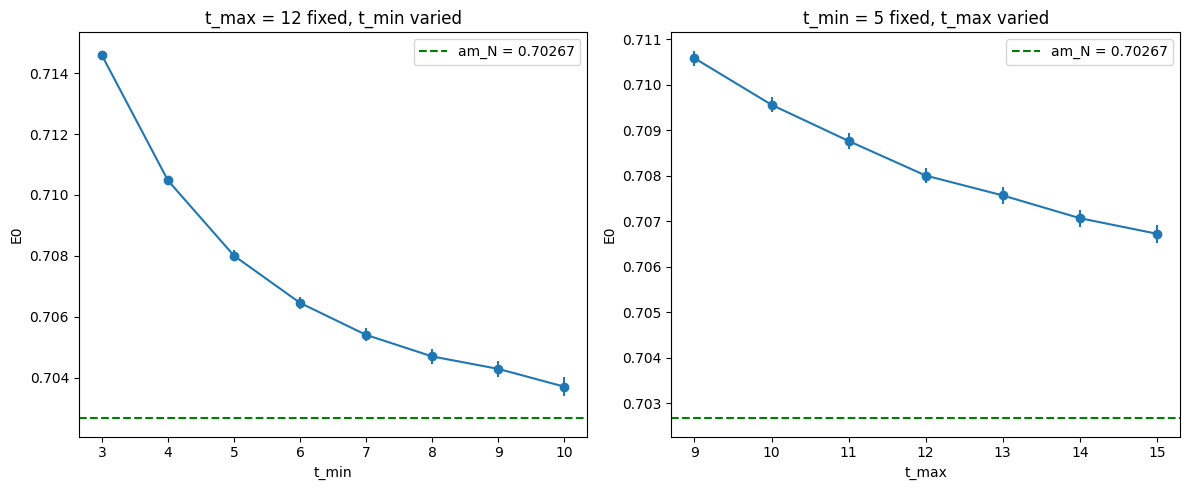


Single-exp fit over t in [7, 12]:
  A  = 0.210090
  E0 = 0.707745 +/- 0.000226

Constant fit to m_eff over t_s in [7.5, 12.5]:
  E0 = 0.705405 +/- 0.000212


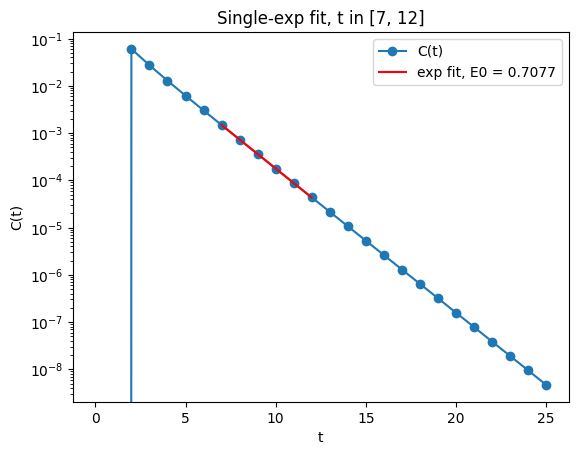

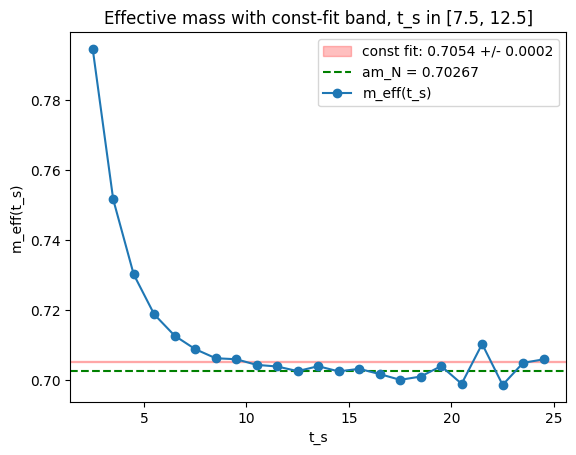

In [ ]:
# =====================================================================
# Single-nucleon: extended stability scan and fits
#
# Joseph's request (Sep 29 email):
#   1. fixed pivot vs moving pivot - single nucleon has no pivot.
#   2. stability plot: vary the fit window and see how E0 moves.
#   3. a fit, not just a flat average.
#
# Physics references:
#   Sarah Eq. (4.2): C(t) = sum_n |Z_n|^2 e^{-E_n t}
#   Sarah Eq. (4.4): m_eff(t) = ln( C(t) / C(t+1) )
#   Sarah Eq. (4.5): lim_{t->inf} m_eff(t) -> E_0
#   Paper Eq. (2.1): C(t) = sum_n |Z_n|^2 e^{-E_n t}
#   Paper Figure 1 caption: m_eff(t_s) = ln( C(t_s - 0.5) / C(t_s + 0.5) )
#   Paper Eq. (2.15): am_N = 0.70267(40)
# =====================================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---- load ----
file_path = "cosmon_c103_r005-8_nucleon.hdf5"
with h5py.File(file_path, "r") as f:
    d1 = f["P000_G1g_1/data"][:]   # (1490, 26)

N_samples, Nt = d1.shape
print("N_samples =", N_samples, " Nt =", Nt)

# ---- helpers ----
def effective_mass(C, t_start=2):
    C = C.real
    ts = np.arange(t_start, len(C) - 1) + 0.5
    with np.errstate(divide="ignore", invalid="ignore"):
        m = np.log(C[t_start:-1] / C[t_start + 1:])
        m = np.where(m > 0, m, np.nan)
    return ts, m

def bootstrap_E0_const(d, t_min, t_max, nboot=1000, seed=12345, t_start=2):
    """Bootstrap the constant fit to m_eff over t_s in [t_min, t_max]."""
    rng = np.random.default_rng(seed)
    Ns = d.shape[0]
    E0_boot = np.full(nboot, np.nan)
    for b in range(nboot):
        idx = rng.integers(0, Ns, size=Ns)
        Cb = d[idx].mean(axis=0).real
        ts_b, m_b = effective_mass(Cb, t_start=t_start)
        mask = (ts_b >= t_min) & (ts_b <= t_max)
        E0_boot[b] = np.nanmean(m_b[mask])
    return np.nanmean(E0_boot), np.nanstd(E0_boot)

def fit_exp(t, A, E):
    return A * np.exp(-E * t)

def fit_E0_exp(d, t_min, t_max, nboot=1000, seed=12345):
    """Single-exp fit C(t) = A exp(-E t) over t in [t_min, t_max]."""
    rng = np.random.default_rng(seed)
    Ns = d.shape[0]
    Cmean = d.mean(axis=0).real
    t = np.arange(len(Cmean))
    mask = (t >= t_min) & (t <= t_max)
    t_fit = t[mask]
    C_fit = Cmean[mask]
    popt, _ = curve_fit(fit_exp, t_fit, C_fit, p0=[1.0, 0.7])
    A0, E0 = popt
    E0_boot = np.full(nboot, np.nan)
    for b in range(nboot):
        idx = rng.integers(0, Ns, size=Ns)
        Cb = d[idx].mean(axis=0).real
        try:
            popt_b, _ = curve_fit(fit_exp, t_fit, Cb[mask], p0=[A0, E0])
            E0_boot[b] = popt_b[1]
        except RuntimeError:
            pass
    return np.nanmean(E0_boot), np.nanstd(E0_boot), A0, E0

# =====================================================================
# Extended scans
# =====================================================================

# ---- scan t_min, t_max fixed ----
t_min_scan = [3, 4, 5, 6, 7, 8, 9, 10]
t_max_fixed = 12

print("Scan: t_max =", t_max_fixed, " fixed, t_min varied")
E0_vs_tmin, E0err_vs_tmin = [], []
for tmin in t_min_scan:
    E0, Eerr = bootstrap_E0_const(d1, tmin + 0.5, t_max_fixed + 0.5)
    E0_vs_tmin.append(E0)
    E0err_vs_tmin.append(Eerr)
    print(f"  t_min = {tmin}, t_max = {t_max_fixed}: E0 = {E0:.6f} +/- {Eerr:.6f}")

# ---- scan t_max, t_min fixed ----
t_min_fixed = 5
t_max_scan = [9, 10, 11, 12, 13, 14, 15]

print()
print("Scan: t_min =", t_min_fixed, " fixed, t_max varied")
E0_vs_tmax, E0err_vs_tmax = [], []
for tmax in t_max_scan:
    E0, Eerr = bootstrap_E0_const(d1, t_min_fixed + 0.5, tmax + 0.5)
    E0_vs_tmax.append(E0)
    E0err_vs_tmax.append(Eerr)
    print(f"  t_min = {t_min_fixed}, t_max = {tmax}: E0 = {E0:.6f} +/- {Eerr:.6f}")

# ---- stability plots ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(t_min_scan, E0_vs_tmin, yerr=E0err_vs_tmin, fmt="o-")
axes[0].axhline(0.70267, color="green", linestyle="--", label="am_N = 0.70267")
axes[0].set_xlabel("t_min")
axes[0].set_ylabel("E0")
axes[0].set_title(f"t_max = {t_max_fixed} fixed, t_min varied")
axes[0].legend()

axes[1].errorbar(t_max_scan, E0_vs_tmax, yerr=E0err_vs_tmax, fmt="o-")
axes[1].axhline(0.70267, color="green", linestyle="--", label="am_N = 0.70267")
axes[1].set_xlabel("t_max")
axes[1].set_ylabel("E0")
axes[1].set_title(f"t_min = {t_min_fixed} fixed, t_max varied")
axes[1].legend()

plt.tight_layout()
plt.show()

# =====================================================================
# Fits over the chosen window
# =====================================================================

t_min_fit = 7
t_max_fit = 12

E0_exp, E0_exp_err, A0, E0_exp_mean = fit_E0_exp(d1, t_min_fit, t_max_fit)
print()
print(f"Single-exp fit over t in [{t_min_fit}, {t_max_fit}]:")
print(f"  A  = {A0:.6f}")
print(f"  E0 = {E0_exp:.6f} +/- {E0_exp_err:.6f}")

E0_const, E0_const_err = bootstrap_E0_const(d1, t_min_fit + 0.5, t_max_fit + 0.5)
print()
print(f"Constant fit to m_eff over t_s in [{t_min_fit + 0.5}, {t_max_fit + 0.5}]:")
print(f"  E0 = {E0_const:.6f} +/- {E0_const_err:.6f}")

# ---- correlator with exp fit overlay ----
plt.figure()
t = np.arange(Nt)
Cmean = d1.mean(axis=0).real
plt.plot(t, Cmean, "o-", label="C(t)")
t_dense = np.linspace(t_min_fit, t_max_fit, 200)
plt.plot(t_dense, fit_exp(t_dense, A0, E0_exp_mean), "r-",
         label=f"exp fit, E0 = {E0_exp_mean:.4f}")
plt.yscale("log")
plt.xlabel("t")
plt.ylabel("C(t)")
plt.title(f"Single-exp fit, t in [{t_min_fit}, {t_max_fit}]")
plt.legend()
plt.show()

# ---- effective mass with constant band ----
ts, m1 = effective_mass(d1.mean(axis=0).real)

plt.figure()
plt.errorbar(ts, m1, fmt="o-", label="m_eff(t_s)")
plt.axhspan(E0_const - E0_const_err, E0_const + E0_const_err,
            color="red", alpha=0.25,
            label=f"const fit: {E0_const:.4f} +/- {E0_const_err:.4f}")
plt.axhline(0.70267, color="green", linestyle="--",
            label="am_N = 0.70267")
plt.xlabel("t_s")
plt.ylabel("m_eff(t_s)")
plt.title(f"Effective mass with const-fit band, t_s in [{t_min_fit+0.5}, {t_max_fit+0.5}]")
plt.legend()
plt.show()